### Build a Basic Chatbot using Langgraph (Graph API)

In [67]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [68]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messsages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [69]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [70]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [71]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [72]:
graph_builder=StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

In [73]:
## Compile the graph
graph = graph_builder.compile()

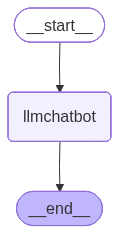

In [74]:
## Visualise the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [75]:
response = graph.invoke({"messages": "Hi"})

In [76]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [77]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


### Chatbot with Tool

In [78]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is Tavily?")

{'query': 'What is Tavily?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aiagentslist.com/agents/tavily',
   'title': 'Tavily Review 2026 | AI Infrastructure & MLOps Tool - Pricing & Features',
   'content': "Tavily gives AI tools real-time access to the internet. It helps AI agents, chatbots, and research tools get fresh, accurate web data quickly, reducing errors and improving their ability to answer questions and make decisions based on current facts. ### Who It's For. Developers and companies building AI agents, chatbots, or research tools. ### What You Get. You get fast, reliable web search and data extraction through simple APIs. This means your AI systems receive current facts, leading to fewer incorrect answers and better decision-making. You connect your AI using Tavily's easy-to-use APIs. Your AI then sends a query, and Tavily quickly returns relevant, ready-to-use content with source citations. **Real-time Web Data Access**. Of

In [103]:
## Custom function
def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a*b

In [105]:
tools=[tool, multiply]

In [106]:
llm_with_tool=llm.bind_tools(tools)

In [107]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020968445150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000209683F0F90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

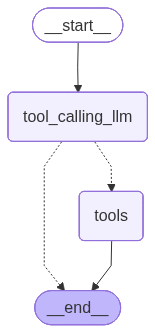

In [108]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## Compiling the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [109]:
response = graph.invoke({
    "messages": [("user", "What is the recent AI news?")]
})

In [110]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.7413937, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial AI continues to build through new deployments, ecosystem partnerships, spectrum initiatives and innovative network applications.*. Twelve months ago, *RCR* might have covered these items individually, in depth, but AI has changed everything, including the news trade and news beat (*so share if you care).* For one, Nokia – which we shall call ECE for now, on the grounds Nokia has put it up for sale, and doesn’t deserve the credit – has started its own little P

In [111]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3q0wt5jdf)
 Call ID: 3q0wt5jdf
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.7413937, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial AI continues to build through new deploym

In [112]:
response = graph.invoke({"messages":"What is 2 multiplied 3"})

In [113]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied 3
================================== Ai Message ==================================
Tool Calls:
  multiply (hqkef5x29)
 Call ID: hqkef5x29
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [115]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 5 by 10."})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nqa8eh0d7)
 Call ID: nqa8eh0d7
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (chw44bw8j)
 Call ID: chw44bw8j
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.7413937, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human 